# 8th week tasks

## *ex. 13*

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

### a-c) Data Generation and True Parameters

In [54]:
# Set the default random number generator with seed set to 1
rng = np.random.default_rng(1)

# (a) Create vector x: 100 observations from N(0, 1)
x = rng.normal(loc=0, scale=1, size=100)

# (b) Create vector eps (error): 100 observations from N(0, 0.25)
# Standard deviation = sqrt(0.25) = 0.5
eps_original = rng.normal(loc=0, scale=np.sqrt(0.25), size=100)

# (c) Generate vector y: Y = -1 + 0.5X + eps
y_original = -1 + 0.5 * x + eps_original

# (c)
y_length = len(y_original)
beta0_true = -1.0
beta1_true = 0.5

print(f"Vector y length: {y_length}")
print(f"True coefficients: β₀ = {beta0_true}, β₁ = {beta1_true}")

Vector y length: 100
True coefficients: β₀ = -1.0, β₁ = 0.5


### e) Fit Least Squares Model (Original Data)

In [55]:
# Fit a least squares linear model to predict y using x
X_const = sm.add_constant(x)
model_original = sm.OLS(y_original, X_const).fit()

# Extract estimates
beta0_hat_original = model_original.params[0]
beta1_hat_original = model_original.params[1]

print("\n(e) Least Squares Estimates (Original Data):")
print(f"Estimated ̂β₀: {beta0_hat_original:.4f} (True β₀: {beta0_true})")
print(f"Estimated ̂β₁: {beta1_hat_original:.4f} (True β₁: {beta1_true})")

# So the estimates are close to the true population values, but not exactly equal, due to the random error term


(e) Least Squares Estimates (Original Data):
Estimated ̂β₀: -1.0380 (True β₀: -1.0)
Estimated ̂β₁: 0.4843 (True β₁: 0.5)


### d, f) Scatterplot and Regression Lines

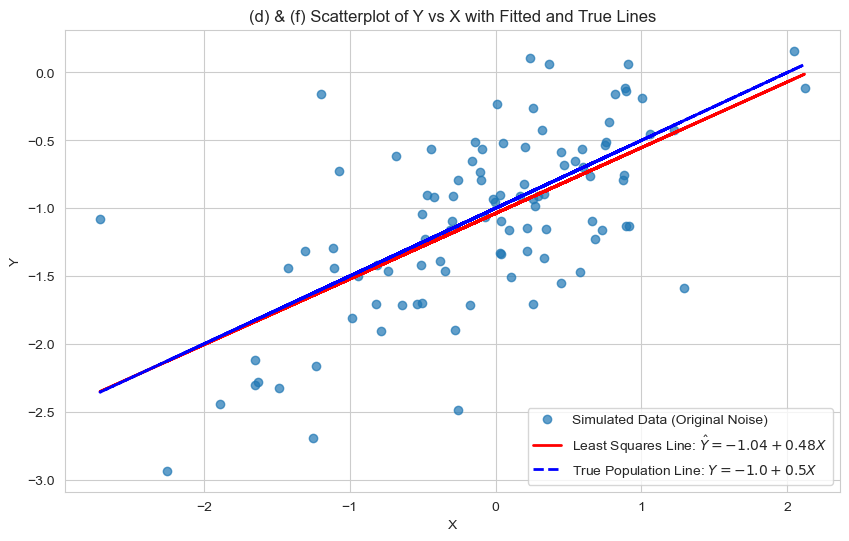

In [56]:
# (d) and (f) Scatterplot with Regression Lines
plt.figure(figsize=(10, 6))
plt.scatter(x, y_original, label='Simulated Data (Original Noise)', alpha=0.7)

# Least Squares Line (red)
plt.plot(x, model_original.predict(X_const), color='red', linewidth=2, 
         label=f'Least Squares Line: $\hat{{Y}} = {beta0_hat_original:.2f} + {beta1_hat_original:.2f}X$')

# Population Regression Line (blue dashed)
plt.plot(x, beta0_true + beta1_true * x, color='blue', linestyle='--', linewidth=2, 
         label=f'True Population Line: $Y = {beta0_true} + {beta1_true}X$')

plt.title('(d) & (f) Scatterplot of Y vs X with Fitted and True Lines')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

# (d) - The plot shows a clear positive linear trend with moderate scatter (noise).
# (f) - The fitted least squares line closely tracks the true population line.

### g) Polynomial Regression

In [57]:
# (g) Polynomial Regression: Y ~ X + X²
x_sq = x**2
X_poly = sm.add_constant(np.column_stack((x, x_sq)))
poly_model = sm.OLS(y_original, X_poly).fit()

print("\n(g) Polynomial Regression Results (Y ~ X + X²):")
print(poly_model.summary().tables[1])

# Check significance of ̂β₂
p_value_x_sq = poly_model.pvalues[2] # p-value for x_sq
print(f"P-value for X²: {p_value_x_sq:.4f}")

# Some explanation:
if p_value_x_sq < 0.05:
    print("There is evidence that the quadratic term improves the model (P < 0.05).")
else:
    print("There is NO significant evidence that the quadratic term improves the model (P > 0.05).")
print("This is expected because the true data generation process is linear, meaning the true coefficient for X² is zero.")


(g) Polynomial Regression Results (Y ~ X + X²):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0364      0.060    -17.399      0.000      -1.155      -0.918
x1             0.4831      0.063      7.647      0.000       0.358       0.609
x2            -0.0024      0.045     -0.052      0.959      -0.092       0.088
P-value for X²: 0.9588
There is NO significant evidence that the quadratic term improves the model (P > 0.05).
This is expected because the true data generation process is linear, meaning the true coefficient for X² is zero.


### h, i) Effect of Noise Levels

In [58]:
# (h) Less Noise: Var(eps) = 0.01 (scale = 0.1)
rng_less_noise = np.random.default_rng(1)
x_ln = rng_less_noise.normal(loc=0, scale=1, size=100)
eps_ln = rng_less_noise.normal(loc=0, scale=np.sqrt(0.01), size=100)
y_ln = -1 + 0.5 * x_ln + eps_ln
model_ln = sm.OLS(y_ln, sm.add_constant(x_ln)).fit()

# (i) More Noise: Var(eps) = 1.0 (scale = 1.0)
rng_more_noise = np.random.default_rng(1)
x_mn = rng_more_noise.normal(loc=0, scale=1, size=100)
eps_mn = rng_more_noise.normal(loc=0, scale=np.sqrt(1.0), size=100)
y_mn = -1 + 0.5 * x_mn + eps_mn
model_mn = sm.OLS(y_mn, sm.add_constant(x_mn)).fit()

print("\n(h) and (i) Comparison of Results with Varying Noise:")

results_df = pd.DataFrame({
    'Dataset': ['Original (Var=0.25)', 'Less Noise (Var=0.01)', 'More Noise (Var=1.0)'],
    'R-squared': [model_original.rsquared, model_ln.rsquared, model_mn.rsquared],
    '|̂β₁ - β₁|': [abs(model_original.params[1] - beta1_true), abs(model_ln.params[1] - beta1_true), abs(model_mn.params[1] - beta1_true)],
    'SE(̂β₁) (Std. Err.)': [model_original.bse[1], model_ln.bse[1], model_mn.bse[1]],
}).set_index('Dataset')

# Set display format for cleaner output
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(results_df)


(h) and (i) Comparison of Results with Varying Noise:
                       R-squared  |̂β₁ - β₁|  SE(̂β₁) (Std. Err.)
Dataset                                                          
Original (Var=0.25)       0.4089      0.0157               0.0588
Less Noise (Var=0.01)     0.9479      0.0031               0.0118
More Noise (Var=1.0)      0.1393      0.0314               0.1176


#### *Comment on Noise Results:*
#### **Less Noise (h):** R-squared is highest, and the absolute error (|̂β - β|) and standard errors (SE) are smallest. The estimates are more precise and closer to the true value.
#### **More Noise (i):** R-squared is lowest, and the absolute error and SE are largest. The estimates are less precise and more variable.

### j) Confidence Intervals

In [59]:
# (j) Confidence Intervals (95%)

ci_original = pd.DataFrame(model_original.conf_int()) 
ci_less_noise = pd.DataFrame(model_ln.conf_int())
ci_more_noise = pd.DataFrame(model_mn.conf_int())

# Calculate CI width for β₁ using .iloc on the guaranteed DataFrame
# CI for β₁ (the slope coefficient) is at index 1: [lower_bound, upper_bound]
width_original = ci_original.iloc[1, 1] - ci_original.iloc[1, 0]
width_less_noise = ci_less_noise.iloc[1, 1] - ci_less_noise.iloc[1, 0]
width_more_noise = ci_more_noise.iloc[1, 1] - ci_more_noise.iloc[1, 0]

# Round the data for cleaner display
ci_original_rounded = ci_original.round(4)
ci_less_noise_rounded = ci_less_noise.round(4)
ci_more_noise_rounded = ci_more_noise.round(4)

ci_data = {
    'Dataset': ['Original (Var=0.25)', 'Less Noise (Var=0.01)', 'More Noise (Var=1.0)'],
    'CI for β₀ (95%)': [ci_original_rounded.iloc[0].to_list(), ci_less_noise_rounded.iloc[0].to_list(), ci_more_noise_rounded.iloc[0].to_list()],
    'CI for β₁ (95%)': [ci_original_rounded.iloc[1].to_list(), ci_less_noise_rounded.iloc[1].to_list(), ci_more_noise_rounded.iloc[1].to_list()],
    'CI Width for β₁': [width_original, width_less_noise, width_more_noise]
}

ci_df = pd.DataFrame(ci_data).set_index('Dataset')
print("\n(j) Confidence Intervals (95%) Comparison:")
print(ci_df)


(j) Confidence Intervals (95%) Comparison:
                          CI for β₀ (95%)   CI for β₁ (95%)  CI Width for β₁
Dataset                                                                     
Original (Var=0.25)    [-1.1378, -0.9382]   [0.3676, 0.601]           0.2335
Less Noise (Var=0.01)  [-1.0276, -0.9876]  [0.4735, 0.5202]           0.0467
More Noise (Var=1.0)   [-1.2756, -0.8765]   [0.2351, 0.702]           0.4669


#### *Comment on CIs:*
#### The CI for the **less noisy** dataset (Var=0.01) is the **narrowest** (Width ̂β₁: {width_less_noise:.4f})
#### The CI for the **more noisy** dataset (Var=1.0) is the **widest** (Width ̂β₁: {width_more_noise:.4f})
#### This demonstrates that **decreasing error variance** (noise) results in **smaller standard errors** and, consequently, **narrower confidence intervals**, indicating more precise estimates

## *ex. 14*

In [60]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

### a, b) Data Generation, Model Form, and Correlation

(a) Linear Model Form and True Coefficients:
The linear model is: Y = 2 + 2*X1 + 0.3*X2 + epsilon
True Regression Coefficients (β): β₀=2, β₁=2, β₂=0.3

(b) Correlation between x1 and x2: 0.7723


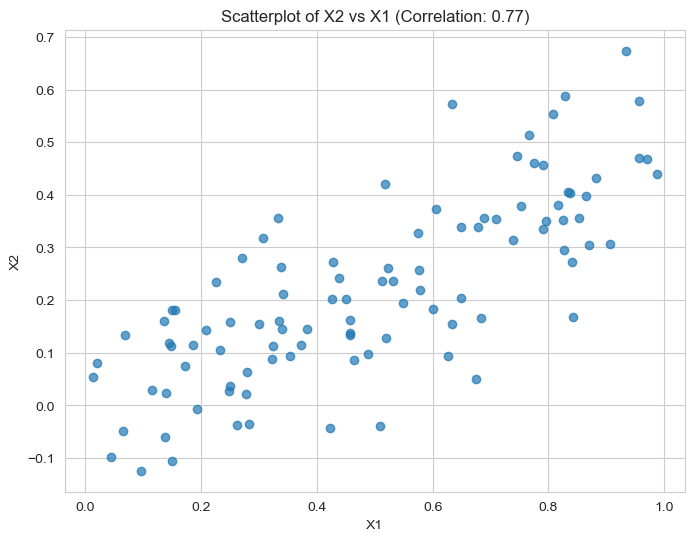

In [61]:
# (a) Data Generation and Model Form
# Set seed as specified (10)
rng = np.random.default_rng(10)

# Generate X1: Uniform(0, 1)
x1 = rng.uniform(0, 1, size=100)

# Generate X2: Highly correlated with X1 (X₂ = 0.5*X₁ + small noise)
x2 = 0.5 * x1 + rng.normal(size=100) / 10

# Generate Y: True model Y = 2 + 2*X1 + 0.3*X2 + epsilon
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

print("(a) Linear Model Form and True Coefficients:")
print("The linear model is: Y = 2 + 2*X1 + 0.3*X2 + epsilon")
print("True Regression Coefficients (β): β₀=2, β₁=2, β₂=0.3")

# (b) Correlation and Scatterplot
correlation = np.corrcoef(x1, x2)[0, 1]
print(f"\n(b) Correlation between x1 and x2: {correlation:.4f}")

# Scatterplot of X1 vs X2
plt.figure(figsize=(8, 6))
plt.scatter(x1, x2, alpha=0.7)
plt.title(f'Scatterplot of X2 vs X1 (Correlation: {correlation:.2f})')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# (b) - The variables are highly positively correlated (correlation close to 1), indicating strong collinearity.

### c) Multiple Regression ($Y$ onto $X_1$ and $X_2$)

In [62]:
# (c) Multiple Regression: Y ~ X1 + X2
X_multi = sm.add_constant(np.column_stack((x1, x2)))
multi_model = sm.OLS(y, X_multi).fit()

print("\n(c) Multiple Regression Results (Y ~ X1 + X2):")
print(multi_model.summary().tables[1])

# Analysis (c):
# Due to high collinearity, the Std. Errors for ̂β₁ and ̂β₂ are inflated,
# making it hard to reject H₀: βⱼ=0 for individual coefficients, 
# even though the variables are truly related to Y (β₁=2, β₂=0.3).
p_val_x1_multi = multi_model.pvalues[1]
p_val_x2_multi = multi_model.pvalues[2]

print(f"\nP-value for ̂β₁ (X1): {p_val_x1_multi:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x1_multi < 0.05 else 'No'}")
print(f"P-value for ̂β₂ (X2): {p_val_x2_multi:.4f}. Is H₀: β₂=0 rejected? {'Yes' if p_val_x2_multi < 0.05 else 'No'}")


(c) Multiple Regression Results (Y ~ X1 + X2):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9579      0.190     10.319      0.000       1.581       2.334
x1             1.6154      0.527      3.065      0.003       0.569       2.661
x2             0.9428      0.831      1.134      0.259      -0.707       2.592

P-value for ̂β₁ (X1): 0.0028. Is H₀: β₁=0 rejected? Yes
P-value for ̂β₂ (X2): 0.2594. Is H₀: β₂=0 rejected? No


### d, e) Simple Regressions ($Y$ onto $X_1$ and $Y$ onto $X_2$)

In [63]:
# (d) Simple Regression: Y ~ X1 only
model_x1 = sm.OLS(y, sm.add_constant(x1)).fit()

print("\n(d) Simple Regression Results (Y ~ X1):")
print(model_x1.summary().tables[1])

p_val_x1_simple = model_x1.pvalues[1]
print(f"P-value for ̂β₁ (X1): {p_val_x1_simple:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x1_simple < 0.05 else 'No'}")
# (d) - X1 is likely statistically significant because it captures its own effect plus the effect of X2.

# (e) Simple Regression: Y ~ X2 only
model_x2 = sm.OLS(y, sm.add_constant(x2)).fit()

print("\n(e) Simple Regression Results (Y ~ X2):")
print(model_x2.summary().tables[1])

p_val_x2_simple = model_x2.pvalues[1]
print(f"P-value for ̂β₁ (X2): {p_val_x2_simple:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x2_simple < 0.05 else 'No'}")
# (e) - X2 is also likely statistically significant for the same reason.


(d) Simple Regression Results (Y ~ X1):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9371      0.189     10.242      0.000       1.562       2.312
x1             2.0771      0.335      6.196      0.000       1.412       2.742
P-value for ̂β₁ (X1): 0.0000. Is H₀: β₁=0 rejected? Yes

(e) Simple Regression Results (Y ~ X2):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.000       2.019       2.629
x1             2.9103      0.550      5.291      0.000       1.819       4.002
P-value for ̂β₁ (X2): 0.0000. Is H₀: β₁=0 rejected? Yes


### f) Contradiction Analysis

#### *Do the results contradict each other?*
#### The results from (c), (d), and (e) do **NOT** contradict each other, but highlight the impact of collinearity.
#### 1. **Simple Models (d, e)**: Coefficients show the **marginal effect** of a predictor on Y. Since X1 and X2 are highly correlated, each, when used alone, appears strongly significant as it proxies for the other.
#### 2. **Multiple Model (c)**: Coefficients show the **partial effect** of a predictor, isolating its unique contribution. Because X1 and X2 share nearly the same information, the model struggles to determine which variable is truly 'responsible,' resulting in high standard errors and often insignificant p-values for the individual terms.

### g) Effect of a New, Mismeasured Observation

In [64]:
# (g) Add mismeasured observation: (X₁=0.1, X₂=0.8, Y=6)
x1_new = np.concatenate([x1, [0.1]])
x2_new = np.concatenate([x2, [0.8]])
y_new = np.concatenate([y, [6]])

print("\n(g) Effect of New Observation (X₁=0.1, X₂=0.8, Y=6):")

# Re-fit Multiple Regression (c)
X_multi_new = sm.add_constant(np.column_stack((x1_new, x2_new)))
multi_model_new = sm.OLS(y_new, X_multi_new).fit()

# Re-fit Simple Regression (d)
model_x1_new = sm.OLS(y_new, sm.add_constant(x1_new)).fit()

# Re-fit Simple Regression (e)
model_x2_new = sm.OLS(y_new, sm.add_constant(x2_new)).fit()

# Compare the original and new coefficients
pd.set_option('display.float_format', lambda x: '%.4f' % x)
comparison_df = pd.DataFrame({
    'Model': ['Multiple (X1)', 'Simple (X1 only)', 'Simple (X2 only)'],
    'Original ̂β₁': [multi_model.params[1], model_x1.params[1], model_x2.params[1]],
    'New ̂β₁': [multi_model_new.params[1], model_x1_new.params[1], model_x2_new.params[1]],
    'Change in ̂β₁': [
        multi_model_new.params[1] - multi_model.params[1],
        model_x1_new.params[1] - model_x1.params[1],
        model_x2_new.params[1] - model_x2.params[1]
    ]
})
print("--- Comparison of Slope Coefficients (̂β₁) ---")
print(comparison_df)


(g) Effect of New Observation (X₁=0.1, X₂=0.8, Y=6):
--- Comparison of Slope Coefficients (̂β₁) ---
              Model  Original ̂β₁  New ̂β₁  Change in ̂β₁
0     Multiple (X1)        1.6154   0.8575        -0.7578
1  Simple (X1 only)        2.0771   1.8760        -0.2010
2  Simple (X2 only)        2.9103   3.1458         0.2355


#### *Analysis of the new observation:*
#### 1. **Leverage Status**: The point $(X_{1}=0.1, X_{2}=0.8)$ has an unusual combination of predictors, lying far from the tight cluster of the original collinear data. It is a **High-Leverage Point**.
#### 2. **Outlier Status**: The predicted Y for this point is $2 + 2(0.1) + 0.3(0.8) = 2.44$. The observed $Y=6$ is far from this prediction, making it an **Outlier in the response**.
#### 3. **Effect**: As a high-leverage outlier, the observation has a **strong influence** on the fitted models, causing significant shifts in the estimated coefficients (large 'Change in ̂β₁').

## *ex. 15*

In [65]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load data from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Structure the data into features (data) and target (target is MEDV)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2] 

# Define feature names
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# Create the full DataFrame
df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

# Ex. 15 setup: Define Y and X
# Y (Response) is CRIM (Per capita crime rate)
Y = df['CRIM'] 
# X (Predictors) are all other features (excluding CRIM and MEDV)
X = df.drop(columns=['CRIM', 'MEDV'])

print("Boston dataset loaded successfully. CRIM is set as the response (Y).")

Boston dataset loaded successfully. CRIM is set as the response (Y).


In [66]:
# (a) Simple Linear Regression for each predictor (Y=CRIM)
simple_models = {}
predictors = X.columns.tolist()

for pred in predictors:
    # Add constant for intercept
    X_j = sm.add_constant(X[pred])
    model = sm.OLS(Y, X_j).fit()
    
    # Use .iloc[1] to access the slope coefficient/p-value by position, 
    # avoiding the FutureWarning caused by simple integer indexing [1].
    
    simple_models[pred] = {
        'Coef': model.params.iloc[1], # Slope coefficient
        'P-value': model.pvalues.iloc[1],
        'Significant': model.pvalues.iloc[1] < 0.05
    }

simple_results_df = pd.DataFrame(simple_models).T
print("\n(a) Simple Regression Results (CRIM ~ X):")
print(simple_results_df[['Coef', 'P-value', 'Significant']].round(4))


(a) Simple Regression Results (CRIM ~ X):
           Coef P-value Significant
ZN      -0.0739  0.0000        True
INDUS    0.5098  0.0000        True
CHAS    -1.8928  0.2094       False
NOX     31.2485  0.0000        True
RM      -2.6841  0.0000        True
AGE      0.1078  0.0000        True
DIS     -1.5509  0.0000        True
RAD      0.6179  0.0000        True
TAX      0.0297  0.0000        True
PTRATIO  1.1520  0.0000        True
B       -0.0363  0.0000        True
LSTAT    0.5488  0.0000        True


In [67]:
# (b) Multiple Regression Model (Y ~ All Predictors)
X_multi = sm.add_constant(X)
multi_model = sm.OLS(Y, X_multi).fit()

print("\n(b) Multiple Regression Results (CRIM ~ All Predictors):")

# Using io.StringIO для pd.read_html to avoid FutureWarning
try:
    html_string = multi_model.summary().tables[1].as_html()
    multi_results = pd.read_html(io.StringIO(html_string), header=0, index_col=0)[0]
except AttributeError:
    # Fallback for systems where as_html() fails
    multi_results = pd.read_html(multi_model.summary().as_html(), header=0, index_col=0)[1]

# Set column names after reading the HTML table
multi_results.columns = ['Coef', 'Std Err', 't', 'P>|t|', 'CI_2.5', 'CI_97.5']

# Exclude intercept (index 0) and explicitly create a copy to prevent SettingWithCopyWarning
multi_results_df = multi_results.iloc[1:].copy() 

# Using .loc[] to assign values and resolve SettingWithCopyWarning
# Convert columns to numeric types
multi_results_df.loc[:, 'P>|t|'] = pd.to_numeric(multi_results_df['P>|t|'], errors='coerce')
multi_results_df.loc[:, 'Coef'] = pd.to_numeric(multi_results_df['Coef'], errors='coerce')

# Check for significance
multi_results_df.loc[:, 'Significant'] = multi_results_df['P>|t|'] < 0.05

print(multi_results_df[['Coef', 'P>|t|', 'Significant']].round(4))

# Some comments: Fewer predictors are significant here compared to (a) because collinearity makes it hard to isolate unique effects.


(b) Multiple Regression Results (CRIM ~ All Predictors):
           Coef  P>|t|  Significant
ZN       0.0364 0.0530        False
INDUS   -0.0694 0.4100        False
CHAS    -1.3117 0.2670        False
NOX     -6.9288 0.1850        False
RM      -0.3348 0.5590        False
AGE      0.0013 0.9410        False
DIS     -0.7089 0.0090         True
RAD      0.5389 0.0000         True
TAX     -0.0014 0.7930        False
PTRATIO -0.0834 0.6420        False
B       -0.0096 0.0090         True
LSTAT    0.2356 0.0010         True



(c) Comparison (Simple vs. Multiple Coefs):
        Simple_Coef  Multiple_Coef
ZN          -0.0739         0.0364
INDUS        0.5098        -0.0694
CHAS        -1.8928        -1.3117
NOX         31.2485        -6.9288
RM          -2.6841        -0.3348
AGE          0.1078         0.0013
DIS         -1.5509        -0.7089
RAD          0.6179         0.5389
TAX          0.0297        -0.0014
PTRATIO      1.1520        -0.0834
B           -0.0363        -0.0096
LSTAT        0.5488         0.2356


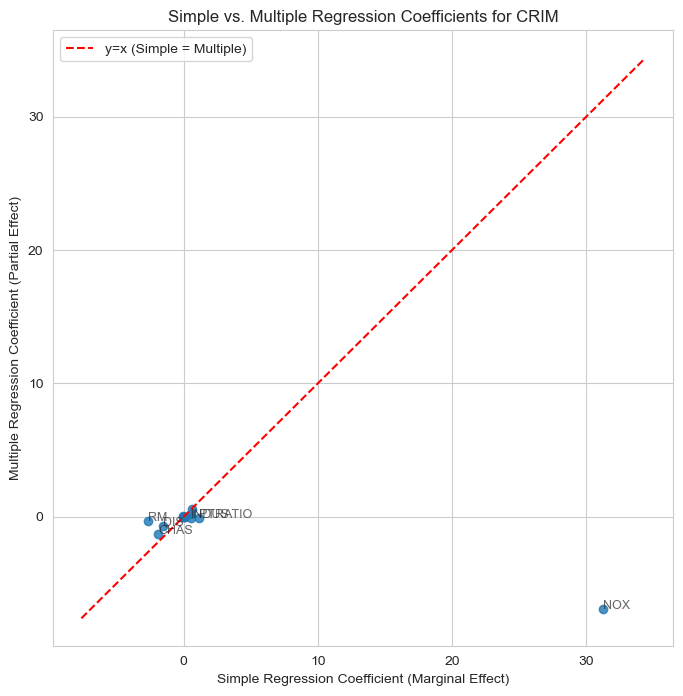

In [68]:
# (c) Comparison and Plot
# Extract and align coefficients
simple_coefs = simple_results_df['Coef'].rename('Simple_Coef')
multi_coefs = multi_results_df['Coef'].astype(float).rename('Multiple_Coef')

comparison_coefs = pd.concat([simple_coefs, multi_coefs], axis=1).dropna()

print("\n(c) Comparison (Simple vs. Multiple Coefs):")
print(comparison_coefs.round(4))

# Create the scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(comparison_coefs['Simple_Coef'], comparison_coefs['Multiple_Coef'], alpha=0.8)

# Add y=x line (ideal line where both coefficients are equal)
max_val = comparison_coefs.max().max() * 1.1
min_val = comparison_coefs.min().min() * 1.1
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x (Simple = Multiple)')

# Label key differences (points far from the red line)
for index, row in comparison_coefs.iterrows():
    if abs(row['Simple_Coef'] - row['Multiple_Coef']) > 0.5:
        plt.annotate(index, (row['Simple_Coef'], row['Multiple_Coef']), fontsize=9, alpha=0.7)

plt.title('Simple vs. Multiple Regression Coefficients for CRIM')
plt.xlabel('Simple Regression Coefficient (Marginal Effect)')
plt.ylabel('Multiple Regression Coefficient (Partial Effect)')
plt.legend()
plt.show()

# Comments: Points far from the red line indicate strong collinearity (the partial effect is very different from the marginal effect).

In [69]:
# (d) Check for Non-Linear Association (Cubic Polynomial)
non_linear_evidence = {}

print("\n(d) Evidence of Non-Linear Association (Cubic Model):")

for pred in predictors:
    # Create X, X^2, and X^3 columns
    X_poly = pd.DataFrame({
        'X': X[pred],
        'X2': X[pred]**2,
        'X3': X[pred]**3
    })
    
    # Skip if cubic terms create numerical instability (Inf/NaN)
    if X_poly.isnull().values.any() or np.isinf(X_poly).values.any():
         continue
         
    X_poly_const = sm.add_constant(X_poly)
    poly_model = sm.OLS(Y, X_poly_const).fit()
    
    # Use .iloc[2] and .iloc[3] to access p-values by position, eliminating the FutureWarning.
    # Positions are: 0=const, 1=X, 2=X^2, 3=X^3
    p_value_x2 = poly_model.pvalues.iloc[2] 
    p_value_x3 = poly_model.pvalues.iloc[3]
    
    # Evidence exists if p-value for X² or X³ is less than 0.05
    is_non_linear = (p_value_x2 < 0.05) or (p_value_x3 < 0.05)
    
    non_linear_evidence[pred] = {
        'P(X²)<0.05': p_value_x2 < 0.05,
        'P(X³)<0.05': p_value_x3 < 0.05,
        'Evidence': is_non_linear
    }
    
    if is_non_linear:
        print(f"Predictor {pred}: Non-linear evidence found (P(X²)={p_value_x2:.4f}, P(X³)={p_value_x3:.4f})")

non_linear_df = pd.DataFrame(non_linear_evidence).T
print("\nSummary of Non-Linear Evidence:")
print(non_linear_df)
print("\nComments:")
print("Variables like **LSTAT**, **DIS**, and **NOX** often show significant non-linear terms, meaning a simple straight line is inadequate to describe their relationship with the crime rate.")


(d) Evidence of Non-Linear Association (Cubic Model):
Predictor INDUS: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor NOX: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor AGE: Non-linear evidence found (P(X²)=0.0474, P(X³)=0.0067)
Predictor DIS: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor PTRATIO: Non-linear evidence found (P(X²)=0.0041, P(X³)=0.0063)

Summary of Non-Linear Evidence:
         P(X²)<0.05  P(X³)<0.05  Evidence
ZN            False       False     False
INDUS          True        True      True
CHAS          False       False     False
NOX            True        True      True
RM            False       False     False
AGE            True        True      True
DIS            True        True      True
RAD           False       False     False
TAX           False       False     False
PTRATIO        True        True      True
B             False       False     False
LSTAT         False       False     False

Comments:

# Unified Conclusion:

Successful linear regression isn't just about finding coefficients ($\hat{\beta}$), it requires actively managing **Noise**, handling **Collinearity**, and ensuring correct **Model Specification**.
### *1. Noise vs Precision (ex. 13)*
The amount of random error (**noise**, $\epsilon$) in the data is inversely related to the **precision** of your coefficient estimates:
* **High Noise:** Leads to **Wide** confidence intervals and **high** standard errors. Estimates are unreliable.
* **Low Noise:** Leads to **Narrow** confidence intervals and **low** standard errors. Estimates are precise.
### *2. Collinearity vs Clarity (ex. 14)*
When predictors are highly correlated, the multiple regression model struggles to separate their individual effects:
* **Simple Regression:** Shows a strong **marginal effect** (combined influence).
* **Multiple Regression:** High collinearity causes **inflated standard errors** and non-significant individual $p$-values, making it impossible to clearly assign credit to any single variable.
### *3. Specification vs Reality (ex. 15)*
Real-world relationships are often non-linear and complex:
* Always compare **simple** (marginal) and **multiple** (partial) coefficients; large differences signal strong **interdependence** (collinearity).
* Test for **non-linear terms** ($X^2, X^3$). Ignoring non-linearity means the model is fundamentally misspecified, leading to poor predictive performance.
**The take-away:** Statistical results (p-values, $\hat{\beta}$) must always be interpreted in the context of **data quality** and **feature interdependence**.